# Speech Recognition with Neural Networks: Utterance to Phoneme Mapping


## 📅 Submission Schedule
- ✅ **Checkpoint:** March 20, 2026 @ 11:59 PM (EST)  
- 🏁 **Final Submission:** March 27, 2026 @ 11:59 PM (EST)  
  *Slack deadline: April 3, 2026 @ 11:59 PM (EST)*  
- 💻 **Code Submission:** 
  - Due: March 29, 2026 @ 11:59PM (EST)
  - Closes: April 3, 2026 @ 11:59 PM (EST) *or day-of via Slack*

## Requirement Acknowledgement

Setting the flag below to **True** indicates that you have read, understood, and agree to comply with **all** of the following requirements:

1. **Slack Days Usage**  
   Slack days may be used **only** for the **P2 Final submission**, *not* for the checkpoint.  
   Specifically, slack days may be applied to submit **final P2 Kaggle scores** to the **Slack Kaggle Competition**, at the expense of your available slack days.

2. **Final Code Submission Deadline**  
   The final **Autolab code submission** is due **within 48 hours after** the Kaggle competition deadline,  
   or **on the same day** as your final Kaggle submission—whichever occurs first.

3. **Kaggle Username & Score Verification**  
   You must provide your **Kaggle username** below. We will use it to retrieve your official **PRIVATE leaderboard** score.  
   Minor score or output variance is acceptable; however, any discrepancies caused by **modifications to the required submission code**
   (including the notebook’s final submission cell) will result in an **Academic Integrity Violation (AIV)**.

4. **Model Implementation Restrictions**  
   You are **not permitted** to use pre-trained or pre-loaded models (e.g., from Hugging Face or similar libraries).  
   You **may** implement models described in research papers or articles, but they **must** be implemented **from scratch**
   using fundamental PyTorch components (e.g., `Linear`, `Conv2d`, etc.).

5. **Data Usage Restrictions**  
   The use of **any external data or datasets** is strictly prohibited at **any stage** of this assignment.

6. **Collaboration Policy**  
   You may collaborate with teammates to run experiments or ablations.  
   However, you must submit **your own code** and **your own results**.

7. **Academic Integrity**  
   Failure to comply with any of the above requirements will be treated as an **Academic Integrity Violation (AIV)**.

8. **Late Submissions**  
   Late submissions **must** be submitted through the **Slack Kaggle Competition** (see write-up for details).  
   Submissions made to the **regular Kaggle competition** after the original deadline will **not** be considered,
   regardless of remaining slack days.


In [ ]:
: Only set Acknowledged to True if you have read the above acknowledgements and agree to ALL of them.
ACKNOWLEDGED = False # @param {"type":"boolean","placeholder":"False"}

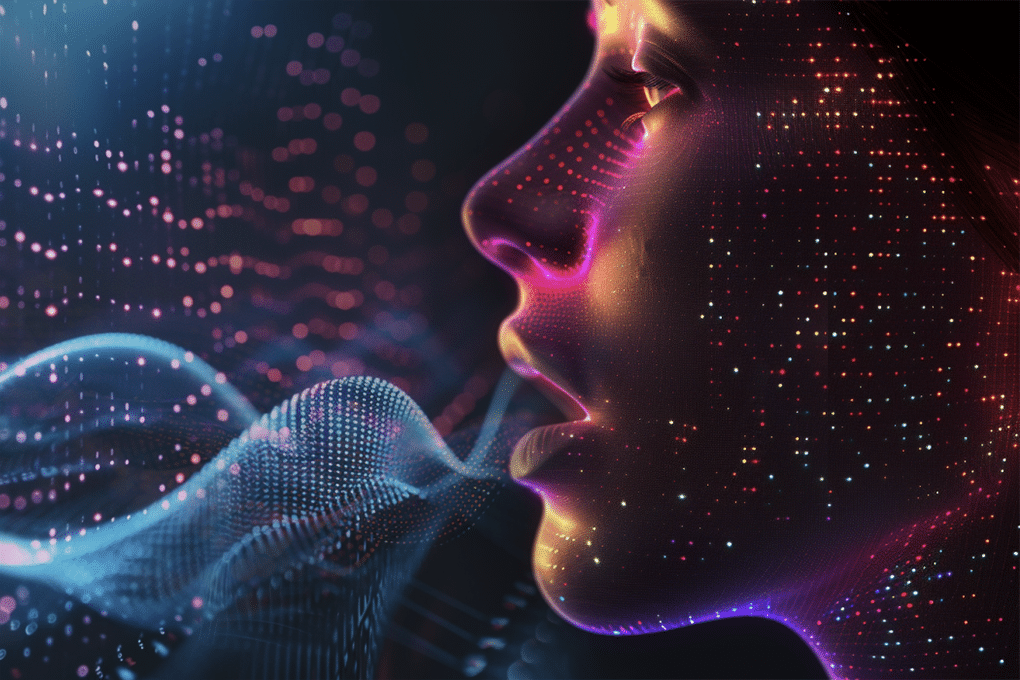

In this assignment, you'll build a sequence-to-sequence model that maps speech utterances to phoneme sequences. You'll implement a recurrent neural network architecture that processes speech feature vectors (MFCCs) and outputs corresponding phoneme sequences.

## Key Components

- **Data Processing**: Work with Mel-Frequency Cepstral Coefficients (MFCCs) and handle variable-length sequences through padding and packing
- **Neural Network Architecture**: Implement a model using CNNs for feature extraction, BiLSTMs for sequential modeling, and optional pyramidal BiLSTMs for downsampling
- **CTC Loss**: Train your model using Connectionist Temporal Classification to handle sequence alignment challenges
- **Decoding Strategies**: Implement both greedy search and beam search for phoneme sequence generation
- **Evaluation**: Use Levenshtein Distance to measure the accuracy of your predicted phoneme sequences

This assignment will give you practical experience with sequence modeling techniques essential to speech recognition systems while exploring various architectural choices and optimization strategies.

# **SET-UP**


Click [**HERE**](https://www.kaggle.com/t/03247d4364694c0286dbe6b70caf0846) to join the competition first!

## [](http://)[](http://)**Colab Users**

### Step 1: Verify GPU
Check that a GPU is available:

In [2]:
!nvidia-smi

Sat Mar 21 11:36:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100-SXM2-32GB           On  |   00000000:B3:00.0 Off |                    0 |
| N/A   31C    P0             40W /  300W |       1MiB /  32768MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Step 2: Install Required Packages

In [3]:
!pip install wandb==0.23.1 torchinfo kaggle==1.8.0 --quiet
!pip install python-Levenshtein --quiet

### Step 3: Configure Kaggle API Access

⚠️ **Important:** You must provide your own Kaggle API credentials for data downloads, while creating your deliverables for code submission and (optionally) submitting to the competition.

#### How to obtain your Kaggle API credentials

1. Navigate to your **Kaggle Profile → Settings** tab.
2. Click **“Genetate New Token”**
3. Copy and paste the access token below

In [130]:
import os
import pprint
os.environ['KAGGLE_USERNAME'] = "<your-username>" # TODO: Verify in Settings
os.environ['KAGGLE_API_TOKEN'] = "<your-key>" # TODO: Add Access Token (must be the new token starting with "KGAT_")

# Verify
import kaggle
api = kaggle.api  # Already authenticated on import
api.competitions_list_cli()

ref                                                                              deadline             category          reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  ---------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/ai-mathematical-olympiad-progress-prize-3    2026-04-15 23:59:00  Featured   2,207,152 Usd       2956           False  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured   1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured   1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured   1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detec

### Step 4: Download Dataset

In [ ]:
api.competition_download_files('11785-hw-3-p-2-utterance-to-phoneme-mapping-spring-2026')
!unzip -qo /content/11785-hw-3-p-2-utterance-to-phoneme-mapping-spring-2026.zip -d /content/dataset
!rm -rf /content/11785-hw-3-p-2-utterance-to-phoneme-mapping-spring-2026.zip

In [ ]:
!du -h --max-depth=2 /content/dataset/11785-hw3p2

## **Kaggle Users**

### Step 1: Environment Setup

In [3]:
!pip install wandb==0.23.1 torchinfo kaggle==1.8.0 --quiet
!pip install python-Levenshtein --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.9/22.9 MB 80.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.3/256.3 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 95.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 3.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 47.2 MB/s eta 0:00:00a 0:00:01


### Step 2: Get Data

If you are using Kaggle, follow these steps to add the dataset directly to your notebook:
1. Join the kaggle competition
2. Open your **Kaggle Notebook**.  
3. Navigate to **Notebook → Input**.  
4. Click **Add Input**.  
5. Choose "Competition Datasets" and "Your work", and then you'll be able to see the competiation "11785 HW3P2 Utterance to Phoneme Mapping S2026"
6. Click the **➕ (plus sign)** to add the dataset to your notebook.  

### Step 3: Configure Kaggle API Access

⚠️ **Important:** You must provide your own Kaggle API credentials while creating your deliverables for code submission and (optionally) submitting to the competition.

#### How to obtain your Kaggle API credentials

1. Navigate to your **Kaggle Profile → Settings** tab.
2. Click **“Genetate New Token”**
3. Copy and paste the access token below


In [4]:
import os
import pprint
os.environ['KAGGLE_USERNAME'] = "andersonawolossou" # TODO: Verify in Settings
os.environ['KAGGLE_API_TOKEN'] = "KGAT_3bacb8b718167d8bee522ef9b8d6c839" # TODO: Add Access Token (must be the new token starting with "KGAT_")

# Verify
import kaggle
api = kaggle.api  # Already authenticated on import
api.competitions_list_cli()

ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/ai-mathematical-olympiad-progress-prize-3    2026-04-15 23:59:00  Featured  2,207,152 Usd       3487           False  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection  

## **PSC Users**

### 1️⃣ **Step 1 Setting Up Your Environment on Bridges2**

❗️⚠️ For this homework, we are **providing a shared Conda environment** for the entire class. Therefore, PSC users **do not need to manually install any packages**.

❗️⚠️ For this homework, you need to **download the dataset to the node `$LOCAL`** to avoid I/O bottlenecks from the shared filesystem. This means that each time you run on a new node, you need to download the dataset again. However, as long as you stay on the same node, you do not need to re-download the dataset. Please refer to **Step 3** for the detailed procedure.

Follow these steps to set up the environment and start a Jupyter notebook on Bridges2:

- To run your notebook more efficiently on PSC, we need to use a **Jupyter Server** hosted on a compute node.

- You can use your prefered way of connecting to the Jupyter Server.  **The recommended way is to connect in VSCode.**
Follow the instructions below.

**The recommended way of connecting is:**

#### **Connect in VSCode**
SSH into Bridges2 and navigate to your **Jet directory** (`Jet/home/<your_psc_username>`). Upload your notebook there, and then connect to the Jupyter Server from that directory.

#### **1. SSH into Bridges2**
1）Open VS Code and click on the `Extensions` icon in the left sidebar. Make sure the "**Remote - SSH**" extension is installed.

2）Open the command palette (**Shift+Command+P** on Mac, **Ctrl+Shift+P** on Windows). A search box will appear at the top center. Choose `"Remote-SSH: Add New SSH Host"`, then enter:

```bash
ssh <your_username>@bridges2.psc.edu #change <your_username> to your username
```

Next, choose `"/Users/<your_username>/.ssh/config"` as the config file. A dialog will appear in the bottom right saying "Host Added". Click `"Connect"`, and then enter your password.

(Note: After adding the host once, you can later use `"Remote-SSH: Connect to Host"` and select "bridges2.psc.edu" from the list.)

3）Once connected, click `"Explorer"` in the left sidebar > "Open Folder", and navigate to your home directory under the project grant:
```bash
/jet/home/<your_username>  #change <your_username> to your username
```

4）You can now drag your notebook files directly into the right-hand pane (your remote home directory), or upload them using `scp` into your folder.

> ❗️⚠️ The following steps should be executed in the **VSCode integrated terminal**.

#### **2. Navigate to Your Directory**
Make sure to use this `/jet/home/<your_username>` as your working directory, since all subsequent operations (up to submission) are based on this path.
```bash
cd /jet/home/<your_username>  #change <your_username> to your username
```

#### **3. Request a Compute Node**
```bash
interact -p GPU-shared --gres=gpu:v100-32:1 -t 8:00:00 -A cis240101p
```

#### **4. Load the Anaconda Module**
```bash
module load anaconda3
```

#### **5. Activate the provided HW3 Environment**
```bash
conda deactivate # First, deactivate any existing Conda environment
conda activate /ocean/projects/cis240101p/mzhang23/TA/envs/IDLS26 && export PYTHONNOUSERSITE=1
```

#### **6. Start Jupyter Notebook**
Launch Jupyter Notebook:
```bash
jupyter notebook --no-browser --ip=0.0.0.0
```

Go to **Kernel** → **Select Another Kernel** → **Existing Jupyter Server**
   Enter the URL of the Jupyter Server:```http://{hostname}:{port}/tree?token={token}```
   
   *(Usually, this URL appears in the terminal output after you run `jupyter notebook --no-browser --ip=0.0.0.0`, in a line like:  “Jupyter Server is running at: http://...”)*

   - eg: `http://v011.ib.bridges2.psc.edu:8888/tree?token=e4b302434e68990f28bc2b4ae8d216eb87eecb7090526249`

> **Note**: Replace `{hostname}`, `{port}` and `{token}` with your actual values from the Jupyter output.

#### **7. Import dependencies**

After launching the Jupyter notebook, you can run the cells directly inside the notebook — no need to use the terminal for the remaining steps.

First, import the dependencies.  
(*If you followed the previous steps and correctly activated our shared `hw3p2` environment, you do **not** need to install anything manually.*)

In [ ]:
# Make sure you are in your directory
!pwd #should be /jet/home/<your_username>, if not, uncomment the following line and replace with your actual username:
%cd /jet/home/awolosso
: replace the "<your_username>" to yours

/kaggle/working
[Errno 2] No such file or directory: '/jet/home/awolosso'
/kaggle/working


### Step 2: Configure Kaggle API Access

⚠️ **Important:** You must provide your own Kaggle API credentials for data downloads, while creating your deliverables for code submission and (optionally) submitting to the competition.

#### How to obtain your Kaggle API credentials

1. Navigate to your **Kaggle Profile → Settings** tab.
2. Click **“Genetate New Token”**
3. Copy and paste the access token below


In [5]:
import os
import pprint
os.environ['KAGGLE_USERNAME'] = "andersonawolossou" # TODO: Verify in Settings
os.environ['KAGGLE_API_TOKEN'] = "KGAT_3bacb8b718167d8bee522ef9b8d6c839" # TODO: Add Access Token (must be the new token starting with "KGAT_")

# Verify
import kaggle
api = kaggle.api  # Already authenticated on import
api.competitions_list_cli()

ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/ai-mathematical-olympiad-progress-prize-3    2026-04-15 23:59:00  Featured  2,207,152 Usd       3418           False  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection  

### Step 3: Get Data

❗️⚠️ In this homework, you need to download the dataset to the **GPU node’s local storage (`$LOCAL`)** instead of using the shared /ocean directory, in order to avoid I/O bottlenecks. Using the shared filesystem may slow down training drastically and can take hours per epoch.

Note that **the local storage on a compute node is temporary and will be cleared** when your node time limit is reached or when you move to a different node. Therefore, **every time you run on a new node, you need to re-run the dataset download step**. However, as long as you stay on the same node, you do NOT need to download the dataset again.

In [ ]:
api.competition_download_files('11785-hw-3-p-2-utterance-to-phoneme-mapping-spring-2026', path=os.environ["LOCAL"])
!mkdir -p $LOCAL/dataset
!unzip -qo $LOCAL/11785-hw-3-p-2-utterance-to-phoneme-mapping-spring-2026.zip -d $LOCAL/dataset
!rm -f $LOCAL/11785-hw-3-p-2-utterance-to-phoneme-mapping-spring-2026.zip

In [ ]:
import os
data_path = "/local/dataset/11785-hw3p2" # this is the path of the dataset on your node
print("Files in shared hw3p2 dataset:", os.listdir(data_path))

In [ ]:
!apt-get install tree
!tree -L 2 /local/dataset/11785-hw3p2

# Imports
(*For PSC users, if you followed the previous steps and correctly activated our shared HW environment, you do **not** need to install anything manually.*)

In [6]:
import torch
import random
import numpy as np
import pandas as pd

import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import wandb
import torchaudio.transforms as tat
from torchaudio.models.decoder import cuda_ctc_decoder
import Levenshtein

from sklearn.metrics import accuracy_score
import gc

import glob

import zipfile
from tqdm.auto import tqdm
import os
import datetime


import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device: ", device)

Device:  cuda


# Config

In [7]:
%%writefile config.yaml

# Subset of dataset to use (1.0 == 100% of data) = when you want to test if your notebook is running, you can use a subset of data
subset: 1.0
learning_rate: 0.001 #0.001 # config['learning_rate'] = 2e-4
epochs: 150
train_beam_width: 3
test_beam_width: 10
mfcc_features: 28 # DO NOT MODIFY


freq_mask_param: 4 #4
time_mask_param: 8 #8

# Set embedding size (the dimensionality of the LSTM hidden state)
embed_size: 256   # {64,128,256} Try out higher embed_size if you have powerfull GPU(RAM) other than T4

batch_size: 256 # 128 # Increase if your device can handle it

encoder dropout: 0.3
lstm dropout: 0.3
decoder dropout: 0.4
wandb: True # Set to True if you want to use WanDB

Name: "Anderson Awolossou" # Write your name here

Overwriting config.yaml


In [8]:
import yaml
with open("config.yaml") as file:
    config = yaml.safe_load(file)

In [9]:
config

{'subset': 1.0,
 'learning_rate': 0.001,
 'epochs': 150,
 'train_beam_width': 3,
 'test_beam_width': 10,
 'mfcc_features': 28,
 'freq_mask_param': 4,
 'time_mask_param': 8,
 'embed_size': 256,
 'batch_size': 256,
 'encoder dropout': 0.3,
 'lstm dropout': 0.3,
 'decoder dropout': 0.4,
 'wandb': True,
 'Name': 'Anderson Awolossou'}

### ⚠️ `Note`

- You will need to set the root path to your `11785-hw3p2` folder in `data: root:`. This will depend on your setup. For eg. if you are following out setup instruction:
  - `Colab:`: `"/content/dataset/11785-hw3p2"`
  - `Kaggle:`: `"/kaggle/input/11785-hw-3-p-2-utterance-to-phoneme-mapping-spring-2026/11785-hw3p2"`
  - `PSC`: `"/local/dataset/11785-hw3p2"`

Kindly modify your configurations to suit your ablations.

In [10]:
BATCH_SIZE = config["batch_size"] # Define batch size from config
root = "/kaggle/input/competitions/11785-hw-3-p-2-utterance-to-phoneme-mapping-spring-2026/11785-hw3p2" # TODO: Specify the directory to your root based on your environment

# Setup Vocabulary (DO NOT MODIFY)

In [11]:
# ARPABET PHONEME MAPPING
# DO NOT CHANGE

CMUdict_ARPAbet = {
    "" : " ",
    "[SIL]": "-", "NG": "G", "F" : "f", "M" : "m", "AE": "@",
    "R"    : "r", "UW": "u", "N" : "n", "IY": "i", "AW": "W",
    "V"    : "v", "UH": "U", "OW": "o", "AA": "a", "ER": "R",
    "HH"   : "h", "Z" :
     "z", "K" : "k", "CH": "C", "W" : "w",
    "EY"   : "e", "ZH": "Z", "T" : "t", "EH": "E", "Y" : "y",
    "AH"   : "A", "B" : "b", "P" : "p", "TH": "T", "DH": "D",
    "AO"   : "c", "G" : "g", "L" : "l", "JH": "j", "OY": "O",
    "SH"   : "S", "D" : "d", "AY": "Y", "S" : "s", "IH": "I",
    "[SOS]": "[SOS]", "[EOS]": "[EOS]"
}


CMUdict = list(CMUdict_ARPAbet.keys())
ARPAbet = list(CMUdict_ARPAbet.values())

PHONEMES = CMUdict[:-2] #To be used for mapping original transcripts to integer indices
LABELS = ARPAbet[:-2] #To be used for mapping predictions to strings

OUT_SIZE = len(PHONEMES) # Number of output classes
print("Number of Phonemes:", OUT_SIZE)

# Indexes of BLANK and SIL phonemes
BLANK_IDX=CMUdict.index('')
SIL_IDX=CMUdict.index('[SIL]')

print("Index of Blank:", BLANK_IDX)
print("Index of [SIL]:", SIL_IDX)

Number of Phonemes: 41
Index of Blank: 0
Index of [SIL]: 1


### Sample data inspection & sanity check

In [12]:
test_mfcc = f"{root}/train-clean-100/mfcc/103-1240-0000.npy"
test_transcript = f"{root}/train-clean-100/transcript/103-1240-0000.npy"

mfcc = np.load(test_mfcc)
transcript = np.load(test_transcript)[1:-1] #Removed [SOS] and [EOS]

print("MFCC Shape:", mfcc.shape)
print("\nMFCC:\n", mfcc)
print("\nTranscript shape:", transcript.shape)

print("\nOriginal Transcript:\n", transcript)

# map the loaded transcript (from phonemes representation) to corresponding labels representation
mapped_transcript = [CMUdict_ARPAbet[k] for k in transcript]
print("\nTranscript mapped from PHONEMES representation to LABELS representation:\n", mapped_transcript)

# Mapping list of PHONEMES to list of Integer indexes
map = {k: i for i, k in enumerate(PHONEMES)}
print("\nMapping list of PHONEMES to list of Integer indexes:\n", map)



MFCC Shape: (1404, 28)

MFCC:
 [[ 1.10582151e+01  1.28330450e+01  2.10689220e+01 ... -8.75406042e-02
   7.30623007e-02  9.48924713e+01]
 [ 1.16850815e+01  1.38329487e+01  2.19087906e+01 ... -1.39180899e-01
  -6.15991093e-02  9.55670319e+01]
 [ 1.11048431e+01  1.67276516e+01  2.28863831e+01 ... -4.03698802e-01
   8.09250996e-02  9.54314651e+01]
 ...
 [ 2.62413955e+00 -1.26996317e+01  2.79472313e+01 ... -1.49060452e+00
  -2.67574161e-01  1.16191261e+02]
 [ 3.05713993e-02 -1.20763254e+01  2.60116520e+01 ... -8.54688883e-01
  -1.20284989e-01  1.17127373e+02]
 [-1.33604801e+00 -1.17101593e+01  2.44703121e+01 ... -9.30283189e-01
  -8.16672146e-02  1.18280014e+02]]

Transcript shape: (145,)

Original Transcript:
 ['[SIL]' 'CH' 'AE' 'P' 'T' 'ER' 'W' 'AH' 'N' '[SIL]' 'M' 'IH' 'S' 'IH' 'Z'
 'R' 'EY' 'CH' 'AH' 'L' 'IH' 'N' 'D' 'IH' 'Z' 'S' 'ER' 'P' 'R' 'AY' 'Z'
 'D' '[SIL]' 'M' 'IH' 'S' 'IH' 'Z' 'R' 'EY' 'CH' 'AH' 'L' 'IH' 'N' 'D'
 '[SIL]' 'L' 'AY' 'V' 'D' '[SIL]' 'JH' 'AH' 'S' 'T' 'W' 'EH' 'R' '

# Dataset and Dataloader

### Train Data

In [13]:
class AudioDataset(torch.utils.data.Dataset):

    def __init__(self, root, phonemes = PHONEMES, partition= "train-clean-100"):
        '''
        Initializes the dataset.
        '''

        self.phonemes   = phonemes
        self.subset = config['subset']

        
        # Initialize augmentations : timemasking and frequencymasking
        self.freq_masking = tat.FrequencyMasking(freq_mask_param=config["freq_mask_param"])
        self.time_masking = tat.TimeMasking(time_mask_param=config["time_mask_param"])

         # MFCC directory - use partition to acces train/dev directories from kaggle data using root
        self.mfcc_dir       = f"{root}/{partition}/mfcc"
        # Transcripts directory - use partition to acces train/dev directories from kaggle data using root
        self.transcript_dir = f"{root}/{partition}/transcript"

        

        # List all files in the directories. Remember to sort the files
        self.mfcc_files =  sorted(os.listdir(self.mfcc_dir))
        self.transcript_files = sorted(os.listdir(self.transcript_dir))

        # Compute size of data subset
        subset_size = int(self.subset * len(self.mfcc_files))

        # Select subset of data to use
        self.mfcc_files = self.mfcc_files[:subset_size]
        self.transcript_files = self.transcript_files[:subset_size]

        assert(len(self.mfcc_files) == len(self.transcript_files))


        
        self.mfccs, self.transcripts = [], []
        eps = 1e-8


        mfcc_names, transcript_names = self.mfcc_files, self.transcript_files
        # Iterate through mfccs and transcripts
        for i in tqdm(range(len(self.mfcc_files))):

            # Load a single mfcc
            mfcc             = np.load(f"{root}/{partition}/mfcc/{mfcc_names[i]}")
            # Cepstral Normalization of mfcc along the Time Dimension
            mean = np.mean(mfcc, axis=0, keepdims=True)
            std = np.std(mfcc, axis=0, keepdims=True)
            mfccs_normalized = (mfcc - mean) / (std + eps)

            # Convert mfcc to tensor
            mfccs_normalized = torch.tensor(mfccs_normalized, dtype=torch.float32)

            # Load the corresponding transcript
            # Remove [SOS] and [EOS] from the transcript
            transcript  = np.load(f"{root}/{partition}/transcript/{transcript_names[i]}")
            transcript = transcript[1:-1]

            # The available phonemes in the transcript are of string data type
            # But the neural network cannot predict strings as such.
            # Hence, we map these phonemes to integers

            # Map the phonemes to their corresponding list indexes in self.phonemes
            transcript_indices = [self.phonemes.index(phoneme) for phoneme in transcript]
            # Now, if an element in the transcript is 0, it means that it is 'SIL' (as per the above example)

            # Convert transcript to tensor
            transcript_indices = torch.tensor(transcript_indices, dtype=torch.int64)

            # Append each mfcc to self.mfcc, transcript to self.transcript
            self.mfccs.append(mfccs_normalized)
            self.transcripts.append(transcript_indices)

        # Length of the dataset is now the length of concatenated mfccs/transcripts
        self.length = len(self.mfccs)



    def __len__(self):

        return self.length


    def __getitem__(self, ind):

        '''
        RETURN THE MFCC COEFFICIENTS AND ITS CORRESPONDING LABELS

        If you didn't do the loading and processing of the data in __init__,
        do that here.

        Once done, return a tuple of features and labels.

        '''

        mfcc = self.mfccs[ind]
        transcript = self.transcripts[ind]

        
        return mfcc, transcript


    def collate_fn(self, batch):
        
            # batch is a list of (mfcc_tensor, transcript_tensor)
            mfccs, transcripts = zip(*batch)
    
            # Actual lengths
            mfcc_lengths = [len(m) for m in mfccs]
            transcript_lengths = [len(t) for t in transcripts]
    
            # Pad sequences
            mfcc_padded = pad_sequence(mfccs, batch_first=True)        # (batch, max_time, freq)
            transcript_padded = pad_sequence(transcripts, batch_first=True)  # (batch, max_label_len)
    
            # Apply augmentations (with proper probability, e.g., 0.8)
            if np.random.rand() < 0.8:
                mfcc_padded = mfcc_padded.transpose(1, 2)   # (batch, freq, time)
                mfcc_padded = self.freq_masking(mfcc_padded)
                mfcc_padded = self.time_masking(mfcc_padded)
                mfcc_padded = mfcc_padded.transpose(1, 2)   # (batch, time, freq)
    
            return mfcc_padded, transcript_padded, torch.tensor(mfcc_lengths), torch.tensor(transcript_lengths)
    

### Test Data

In [14]:


class AudioDatasetTest(torch.utils.data.Dataset):
    
    def __init__(self, root, partition= "test-clean"):
        '''
        Initializes the dataset.
        '''

         # MFCC directory - use partition to acces train/dev directories from kaggle data using root
        self.mfcc_dir       = f"{root}/{partition}/mfcc"
        

        

        # List all files in the directories. Remember to sort the files
        self.mfcc_files =  sorted(os.listdir(self.mfcc_dir))


        
        self.mfccs = []
        eps = 1e-8


        mfcc_names = self.mfcc_files
        # Iterate through mfccs
        for i in tqdm(range(len(self.mfcc_files))):

            # Load a single mfcc
            mfcc = np.load(f"{root}/{partition}/mfcc/{mfcc_names[i]}")
            # Cepstral Normalization of mfcc along the Time Dimension
            mean = np.mean(mfcc, axis=0, keepdims=True)
            std = np.std(mfcc, axis=0, keepdims=True)
            mfccs_normalized = (mfcc - mean) / (std + eps)

            # Convert mfcc to tensor
            mfccs_normalized = torch.tensor(mfccs_normalized, dtype=torch.float32)

           

            # Append each mfcc to self.mfcc
            self.mfccs.append(mfccs_normalized)
        
        # Length of the dataset is now the length of concatenated mfccs
        self.length = len(self.mfccs)



    def __len__(self):

        return self.length


    def __getitem__(self, ind):

        '''
        RETURN THE MFCC

        '''

        mfcc = self.mfccs[ind]
        
        return mfcc



    def collate_fn(self, batch):
        # batch is a list of MFCC tensors
        mfccs = batch
        mfcc_lengths = [len(m) for m in mfccs]
        mfcc_padded = pad_sequence(mfccs, batch_first=True)
        return mfcc_padded, torch.tensor(mfcc_lengths)


### Data loaders

In [15]:
# To free up ram
import gc
gc.collect()

0

In [18]:
# Create a dataset object using the AudioDataset class for the training data
train_data = AudioDataset(root=root)

# Create a dataset object using the AudioDataset class for the validation data
val_data = AudioDataset(root=root, partition="dev-clean")

# Create a dataset object using the AudioTestDataset class for the test data
test_data = AudioDatasetTest(root=root)

  0%|          | 0/28539 [00:00<?, ?it/s]

  0%|          | 0/2703 [00:00<?, ?it/s]

  0%|          | 0/2620 [00:00<?, ?it/s]

In [19]:
# Do NOT forget to pass in the collate function as an argument while creating the dataloader

train_loader = torch.utils.data.DataLoader(
    dataset     = train_data,
    num_workers = 4,
    batch_size  = config['batch_size'],
    pin_memory  = True,
    shuffle     = True,
    collate_fn = train_data.collate_fn
)

val_loader = torch.utils.data.DataLoader(
    dataset     = val_data,
    num_workers = 0,
    batch_size  = config['batch_size'],
    pin_memory  = True,
    shuffle     = False,
    collate_fn = val_data.collate_fn
)

test_loader = torch.utils.data.DataLoader(
    dataset     = test_data,
    num_workers = 0,
    batch_size  = config['batch_size'],
    pin_memory  = True,
    shuffle     = False,
    collate_fn = test_data.collate_fn
)


print("Batch size: ", config['batch_size'])
print("Train dataset samples = {}, batches = {}".format(train_data.__len__(), len(train_loader)))
print("Val dataset samples = {}, batches = {}".format(val_data.__len__(), len(val_loader)))
print("Test dataset samples = {}, batches = {}".format(test_data.__len__(), len(test_loader)))

Batch size:  256
Train dataset samples = 28539, batches = 112
Val dataset samples = 2703, batches = 11
Test dataset samples = 2620, batches = 11


In [20]:
# sanity check
for data in train_loader:
    x, y, lx, ly = data
    print(x.shape, y.shape, lx.shape, ly.shape)
    break

torch.Size([256, 1680, 28]) torch.Size([256, 199]) torch.Size([256]) torch.Size([256])


# Visualize Data

Note: In the visualized graph, do not confuse padded regions of the MFCC sequences with time/freq augmentation masks. Remember all MFCCs were padded to the maximum sequence length

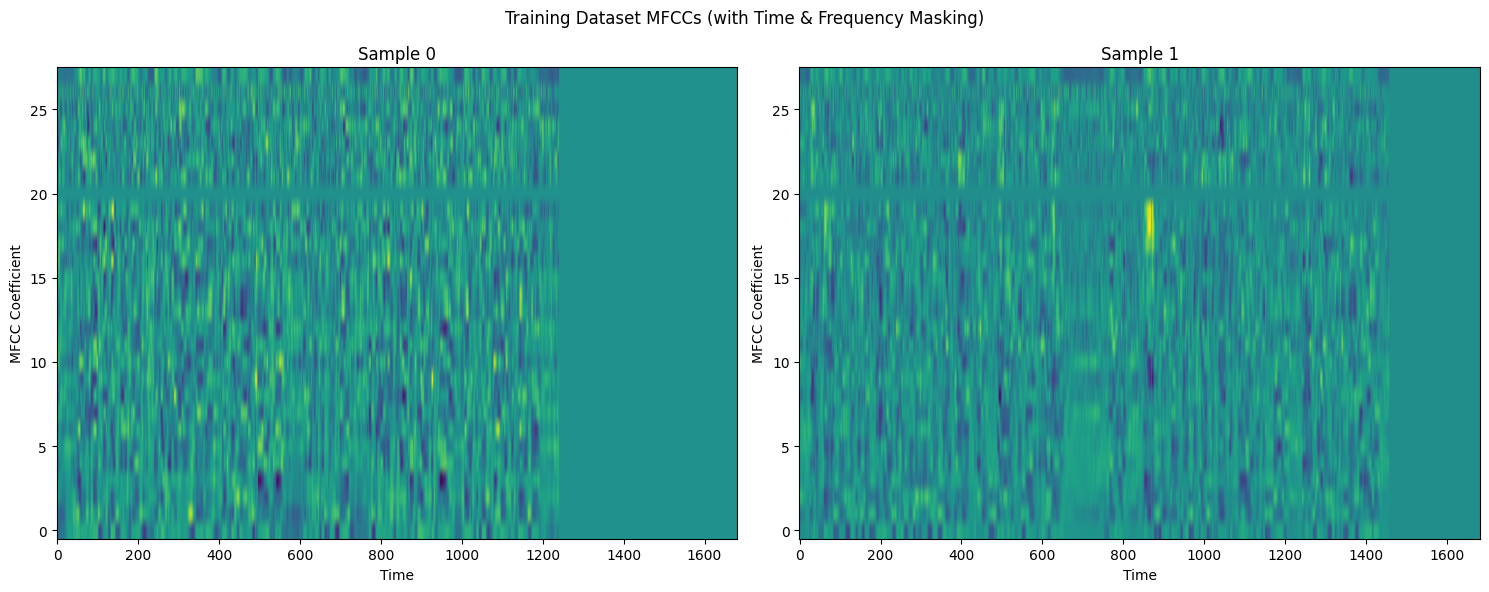

In [21]:
import matplotlib.pyplot as plt

def visualize_batch(loader, title="Dataset Visualization", num_samples=2):
    """
    Visualizes MFCC features from a single batch of data.

    Args:
        loader (DataLoader): DataLoader object (for train, val, or test).
        title (str): Title of the plot.
        num_samples (int): Number of samples to visualize from the batch.
    """
    # Get one batch from the loader.
    batch = next(iter(loader))

    # The collate_fn we defined in the dataset class returns a tuple, where the first element is the padded MFCC tensor.
    mfcc_batch = batch[0] if isinstance(batch, (tuple, list)) else batch

    # Limit to a few samples.
    num_samples = min(num_samples, mfcc_batch.size(0))

    # Create subplots.
    fig, axes = plt.subplots(1, num_samples, figsize=(15,6))
    if num_samples == 1:
        axes = [axes]

    for i in range(num_samples):
        # Each MFCC tensor is of shape [time, frequency].
        # Transpose for visualization: time on x-axis, features on y-axis.
        mfcc_img = mfcc_batch[i].cpu().numpy().T
        im = axes[i].imshow(mfcc_img, origin="lower", aspect="auto", cmap="viridis")
        axes[i].set_title(f"Sample {i}")
        axes[i].set_xlabel("Time")
        axes[i].set_ylabel("MFCC Coefficient")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

# Visualize batches of data
visualize_batch(train_loader, title="Training Dataset MFCCs (with Time & Frequency Masking)")

# Network

## Basic network (Optional)

This is a basic block for understanding, you can skip this and move to pBLSTM one

In [ ]:
torch.cuda.empty_cache()

class Network(nn.Module):

    def __init__(self):

        super(Network, self).__init__()

        # TODO: Adding some sort of embedding layer or feature extractor might help performance.
        # You can use CNNs as Embedding layer to extract features. Keep in mind the Input dimensions and expected dimension of Pytorch CNN.
        # Food for thought -> What type of Conv layers can be used here?
        #                  -> What should be the size of input channels to the first layer?
        self.embedding = _________________________ 

        # TODO : look up the documentation. You might need to pass some additional parameters.
        self.lstm = nn.LSTM(input_size = __________________, hidden_size = 256, num_layers = 3) 

        self.classification = nn.Sequential(
            : Linear layer with in_features from the lstm module above and out_features = OUT_SIZE
        )


        self.logSoftmax =__________________ : Apply a log softmax here. Which dimension would apply it on ?

    def forward(self, x, lx):
        
        # The forward function takes 2 parameter inputs here. Why?
        # Refer to the handout for hints
        x_em = self.embedding(x)
        pack_seq = pack_padded_sequence(x_em, lx, batch_first=True, enforce_sorted=False)
        x, _ = self.lstm(pack_seq)
        x = self.classification(x)
        x = self.logSoftmax(x)
        pass


## Initialize Basic Network
(If trying out the basic Network)

In [21]:
# torch.cuda.empty_cache()

# model = Network().to(device)

# # Check to stay below 20 MIL Parameter limit
# assert sum(p.numel() for p in model.parameters() if p.requires_grad) < 20_000_000, "Exceeds 20 MIL params. Any submission made to Kaggle with this model will be flagged as an AIV."

# print(model)


## ASR Network
We define everything we need for the ASR model in separate classes, and put them all together in the end

#### Permute class

In [22]:
class Permute(torch.nn.Module):
    '''
    Used to transpose/permute the dimensions of an MFCC tensor.
    '''
    def forward(self, x):
        return x.transpose(1, 2)

#### Pyramidal Bi-LSTM (pBLSTM) class

In [23]:
class pBLSTM(torch.nn.Module):

    '''
    Pyramidal BiLSTM
    Read the write up/paper and understand the concepts and then write your implementation here.

    At each step,
    1. Pad your input if it is packed (Unpack it)
    2. Reduce the input length dimension by concatenating feature dimension
        (Tip: Write down the shapes and understand)
        (i) How should  you deal with odd/even length input?
        (ii) How should you deal with input length array (x_lens) after truncating the input?
    3. Pack your input
    4. Pass it into LSTM layer

    To make our implementation modular, we pass 1 layer at a time.
    '''

    def __init__(self, input_size, hidden_size):
        super(pBLSTM, self).__init__()

        # After concatenation, feature size doubles so LSTM input size = 2 * input_size
        self.blstm = nn.LSTM(
            input_size=2 * input_size,
            hidden_size=hidden_size,
            num_layers=1,
            bidirectional=True,
            batch_first=True
        )

    def forward(self, x_packed): # x_packed is a PackedSequence
        # Unpack to padded tensor
        x_padded, lens = pad_packed_sequence(x_packed, batch_first=True)
        # Downsample
        x_down, new_lens = self.trunc_reshape(x_padded, lens)
        # Repack
        x_packed_down = pack_padded_sequence(
            x_down, new_lens.cpu(), batch_first=True, enforce_sorted=False
        )
        # BiLSTM
        out_packed, _ = self.blstm(x_packed_down)
        return out_packed


    def trunc_reshape(self, x, x_lens):
    
        B, T, F = x.shape
    
        if T % 2 != 0:
            x = x[:, :-1, :]
            T = T - 1
    
        x = x.contiguous().view(B, T//2, F*2)
    
        x_lens = x_lens // 2
    
        return x, x_lens


class ResidualBlock1D(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv1 = nn.Conv1d(in_channels, out_channels, 3, padding=1)
        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(out_channels, out_channels, 3, padding=1)
        self.bn2 = nn.BatchNorm1d(out_channels)

        if in_channels != out_channels:
            self.shortcut = nn.Conv1d(in_channels, out_channels, 1)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):

        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.gelu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = F.gelu(out)

        return out

#### Util for LSTM


In [24]:
class LSTMWrapper(torch.nn.Module):
    '''
    Used to get only output of lstm, not the hidden states.
    '''
    def __init__(self, lstm):
        super(LSTMWrapper, self).__init__()
        self.lstm = lstm

    def forward(self, x):
        output, _ = self.lstm(x)
        return output

#### Encoder class

In [25]:
from torch.nn.utils.rnn import PackedSequence


class LockedDropout(nn.Module):
    def __init__(self, p=0.5):
        super().__init__()
        self.p = p

    def forward(self, x):
        if not self.training or self.p == 0:
            return x

        if isinstance(x, PackedSequence):
            mask = x.data.new_empty(x.data.size(0), 1).bernoulli_(1 - self.p).div_(1 - self.p)
            new_data = x.data * mask
            return PackedSequence(new_data, x.batch_sizes,
                                  x.sorted_indices, x.unsorted_indices)
        else:
            return F.dropout(x, p=self.p, training=self.training)

In [27]:


class Encoder(torch.nn.Module):
    '''
    The Encoder takes utterances as inputs and returns latent feature representations
    '''
    def __init__(self, input_size, encoder_hidden_size):
        super(Encoder, self).__init__()

        # CNN embedding (no downsampling yet)
        # self.embedding = nn.Sequential(
        #     nn.Conv1d(input_size, 128, kernel_size=5, padding=2),
        #     nn.BatchNorm1d(128),
        #     nn.GELU(),
        #     nn.Dropout(0.25),
            
        #     nn.Conv1d(128, 256, kernel_size=5, padding=2),
        #     nn.BatchNorm1d(256),
        #     nn.GELU(),
        #     nn.Dropout(0.25)
        # )

        # self.embedding = nn.Sequential(
        #     # nn.Conv1d(input_size, 384, kernel_size=3, padding=1),
        #     # nn.BatchNorm1d(384),
        #     # nn.GELU(),
        #     # nn.Dropout(0.3),

        #     nn.Conv1d(input_size, 256, kernel_size=3, padding=1),
        #     nn.BatchNorm1d(256),
        #     nn.GELU(),
        #     nn.Dropout(0.3),

        #     nn.Conv1d(256, 384, kernel_size=3, padding=1),
        #     nn.BatchNorm1d(384),
        #     nn.GELU(),
        #     nn.Dropout(0.3),
        # )

        # CNN embedding (no downsampling yet)
        self.embedding = nn.Sequential(
            nn.Conv1d(input_size, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.GELU(),

            ResidualBlock1D(128, 256),
            ResidualBlock1D(256, 256),
            
            nn.Dropout(0.3),
            
        )

        
        # Stacked BiLSTM (2 layers)
        self.BLSTMs = nn.LSTM(
            input_size=256,
            hidden_size=encoder_hidden_size,
            num_layers=3,
            bidirectional=True,
            batch_first=True,
            dropout=0.25
        )
        # Pyramidal BiLSTMs (two layers, each downsamples by 2)
        pblstm_input_size = 2 * encoder_hidden_size   # output size of BLSTMs
        self.pBLSTMs = nn.Sequential(
            pBLSTM(pblstm_input_size, encoder_hidden_size),
            #LockedDropout(p=0.3),
            pBLSTM(pblstm_input_size, encoder_hidden_size),
            #LockedDropout(p=0.3),
            #pBLSTM(pblstm_input_size, encoder_hidden_size)
            #LockedDropout(p=0.3),
        )


    def forward(self, x, x_lens):
        # x: (batch, time, freq)   freq = 28
        # Transpose for Conv1d: (batch, freq, time)
        x = x.transpose(1, 2)
        x = self.embedding(x)               # (batch, 256, time)
        x = x.transpose(1, 2)               # (batch, time, 256)

        # Pack for variable-length processing
        x_packed = pack_padded_sequence(
            x, x_lens.cpu(), batch_first=True, enforce_sorted=False
        )

        # BiLSTM
        out_packed, _ = self.BLSTMs(x_packed)

        # pBLSTMs return a packed sequence
        out_packed = self.pBLSTMs(out_packed)

        # Unpack to padded tensor and final lengths
        encoder_out, encoder_lens = pad_packed_sequence(out_packed, batch_first=True)
        
        return encoder_out, encoder_lens

#### Decoder class

In [29]:
class Decoder(torch.nn.Module):

    def __init__(self, embed_size, output_size= 41):
        super().__init__()

        self.mlp = nn.Sequential(
        
            Permute(),
            nn.BatchNorm1d(2*embed_size),
            Permute(),
        
            nn.Linear(2*embed_size, 256),
            nn.GELU(),
            nn.Dropout(0.3),
        
            nn.Linear(256, output_size),
            nn.LogSoftmax(dim=2)
        )

        # self.mlp = nn.Sequential(
        #     Permute(),
        #     nn.BatchNorm1d(2*embed_size),
        #     Permute(),
        
        #     nn.Linear(2*embed_size, 512),
        #     nn.GELU(),
        #     nn.Dropout(0.3),
        
        #     nn.Linear(512, 256),
        #     nn.GELU(),
        #     nn.Dropout(0.3),
        
        #     nn.Linear(256, output_size),
        #     nn.LogSoftmax(dim=2)
        # )


    def forward(self, encoder_out):
        return self.mlp(encoder_out)


# class Decoder(torch.nn.Module):

#     def __init__(self, embed_size, output_size= 41):
#         super().__init__()

#         # embed_size is the hidden size of the encoder LSTM.
#         # Encoder output features = 2 * embed_size (bidirectional)
#         self.mlp = nn.Sequential(
#             Permute(),                          # (B, T, 2*E) -> (B, 2*E, T)
#             nn.BatchNorm1d(2 * embed_size),
#             Permute(),                          # (B, 2*E, T) -> (B, T, 2*E)
#             nn.Linear(2 * embed_size, output_size),
#             nn.LogSoftmax(dim=2)                # log probabilities per time step
#         )

#     def forward(self, encoder_out):
#         return self.mlp(encoder_out)

### ASR Model Class

In [30]:
class ASRModel(torch.nn.Module):

    def __init__(self, input_size, embed_size= 192, output_size= len(PHONEMES)):
        super().__init__()
        self.encoder = Encoder(input_size, embed_size)
        self.decoder = Decoder(embed_size, output_size)

    def forward(self, x, lengths_x):
        encoder_out, encoder_lens = self.encoder(x, lengths_x)
        decoder_out = self.decoder(encoder_out)
        return decoder_out, encoder_lens

## Initialize ASR Network

In [40]:
model = ASRModel(
    input_size=config["mfcc_features"],
    embed_size=config["embed_size"],
    output_size = len(PHONEMES)
).to(device)

# Check to stay below 20 MIL Parameter limit
assert sum(p.numel() for p in model.parameters() if p.requires_grad) < 20_000_000, "Exceeds 20 MIL params. Any submission made to Kaggle with this model will be flagged as an AIV."

In [41]:
summary(model, input_data=[x.to(device), lx.to(device)])

Layer (type:depth-idx)                   Output Shape              Param #
ASRModel                                 [256, 420, 41]            --
├─Encoder: 1-1                           [256, 420, 512]           --
│    └─Sequential: 2-1                   [256, 256, 1680]          --
│    │    └─Conv1d: 3-1                  [256, 128, 1680]          18,048
│    │    └─BatchNorm1d: 3-2             [256, 128, 1680]          256
│    │    └─GELU: 3-3                    [256, 128, 1680]          --
│    │    └─ResidualBlock1D: 3-4         [256, 256, 1680]          329,472
│    │    └─ResidualBlock1D: 3-5         [256, 256, 1680]          394,752
│    │    └─Dropout: 3-6                 [256, 256, 1680]          --
│    └─LSTM: 2-2                         [335964, 512]             4,206,592
│    └─Sequential: 2-3                   [83893, 512]              --
│    │    └─pBLSTM: 3-7                  [167913, 512]             2,625,536
│    │    └─pBLSTM: 3-8                  [83893, 512]   

# N-gram Language Model
Will be used with the decoder

In [42]:
# from collections import defaultdict
# import math

# class NGramLM:
#     def __init__(self, n=2):
#         self.n = n
#         self.ngram_counts = defaultdict(lambda: defaultdict(int))
#         self.context_counts = defaultdict(int)
#         self.vocab = set()

#     def train(self, texts):
#         for text in texts:
#             tokens = ['<s>'] + list(text) + ['</s>']
#             self.vocab.update(tokens)

#             for i in range(len(tokens) - self.n + 1):
#                 context = tuple(tokens[i:i+self.n-1])
#                 word = tokens[i+self.n-1]

#                 self.ngram_counts[context][word] += 1
#                 self.context_counts[context] += 1

#     def get_log_prob(self, context, word):
#         context = tuple(context)

#         count = self.ngram_counts[context].get(word, 0)
#         total = self.context_counts.get(context, 0)

#         # Add-one smoothing
#         prob = (count + 1) / (total + len(self.vocab))
#         return math.log(prob)

# # Extract training text
# def extract_texts(train_loader, LABELS):
#     texts = []

#     for i, data in enumerate(train_loader):
#         x, y, lx, ly = data
#         labels, label_lens = y, ly
        
#         for i in range(len(labels)):
#             length = label_lens[i]
#             seq = labels[i][:length].tolist()

#             text = ''.join([LABELS[idx] for idx in seq if idx != 0])
#             texts.append(text)

#     return texts

# # Train LM
# texts = extract_texts(train_loader, LABELS)

# lm = NGramLM(n=3)  # bigram for n = 2
# lm.train(texts)

# Custom BeamSearchDecoder
Adapted from P1, with batch + log-space + LM

In [43]:
# class BeamSearchDecoder(object):

#     def __init__(self, symbol_set, beam_width, lm=None, alpha=0.5):
#         self.symbol_set = symbol_set
#         self.beam_width = beam_width
#         self.blank = "_"
        
#         # LM
#         self.lm = lm
#         self.alpha = alpha

#     def decode(self, y_probs):
#         """
#         y_probs: (num_symbols+1, T, B)
#         """

#         B = y_probs.shape[2]
#         results = []

#         for b in range(B):

#             T = y_probs.shape[1]

#             # log-space
#             active_paths = {"": 0.0}  # log(1)

#             for t in range(T):

#                 temp_paths = {}

#                 # prune
#                 active_paths = dict(sorted(active_paths.items(), key=lambda x: x[1], reverse=True)[:self.beam_width])

#                 for path, score in active_paths.items():

#                     for i in range(len(self.symbol_set) + 1):

#                         if i == 0:
#                             new_symbol = self.blank
#                         else:
#                             new_symbol = self.symbol_set[i - 1]

#                         new_path = path + new_symbol

#                         # --- CTC collapse logic ---
#                         if new_symbol != self.blank:
#                             if len(new_path) > 1:
#                                 if new_path[-1] == new_path[-2]:
#                                     new_path = new_path[:-1]
#                                 elif new_path[-2] == self.blank:
#                                     new_path = new_path[:-2] + new_path[-1]

#                         # --- scores ---
#                         ctc_score = np.log(y_probs[i, t, b] + 1e-8)

#                         lm_score = 0.0
#                         if self.lm is not None:
#                             prev_char = new_path[-2] if len(new_path) > 1 else '<s>'
#                             curr_char = new_path[-1]
        
#                             lm_score = lm.get_log_prob([prev_char], curr_char)

#                         new_score = score + ctc_score + self.alpha * lm_score

#                         if new_path in temp_paths:
#                             temp_paths[new_path] = np.logaddexp(temp_paths[new_path], new_score)
#                         else:
#                             temp_paths[new_path] = new_score

#                 active_paths = temp_paths

#             # final merge
#             merged = {}
#             for path, score in active_paths.items():
#                 final_path = path.replace(self.blank, "")
#                 if final_path in merged:
#                     merged[final_path] = np.logaddexp(merged[final_path], score)
#                 else:
#                     merged[final_path] = score

#             best_path = max(merged, key=merged.get)
#             results.append(best_path)

#         return results

In [44]:
print(LABELS)

[' ', '-', 'G', 'f', 'm', '@', 'r', 'u', 'n', 'i', 'W', 'v', 'U', 'o', 'a', 'R', 'h', 'z', 'k', 'C', 'w', 'e', 'Z', 't', 'E', 'y', 'A', 'b', 'p', 'T', 'D', 'c', 'g', 'l', 'j', 'O', 'S', 'd', 'Y', 's', 'I']


# Training Config
Initialize Loss Criterion, Optimizer, CTC Beam Decoder, Scheduler, Scaler (Mixed-Precision), etc

In [47]:
# Define CTC loss as the criterion. How would the losses be reduced?
#criterion = nn.CTCLoss(blank=0, reduction='mean')
criterion = nn.CTCLoss(blank=0, reduction='mean')
# CTC Loss: https://pytorch.org/docs/stable/generated/torch.nn.CTCLoss.html
# Refer to the handout for hints

config['weight_decay'] = 0.05
config['learning_rate'] = 0.001
optimizer =  torch.optim.AdamW(model.parameters(), lr=config['learning_rate'], weight_decay=config['weight_decay'])

# Declare the decoder. Use the PyTorch Cuda CTC Decoder to decode phonemes
# CTC Decoder: https://pytorch.org/audio/2.1/generated/torchaudio.models.decoder.cuda_ctc_decoder.html
decoder = cuda_ctc_decoder(
    tokens=LABELS,
    beam_size=config['train_beam_width'],
    nbest=1
)


# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
#     optimizer,
#     T_max = 50,
#     eta_min = 1e-5
# )

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=10
)

# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
#     optimizer,
#     T_max=20, # restart after 20 epochs
#     eta_min=1e-8
# )

# scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
#     optimizer,
#     T_0=20,
#     T_mult=2,
#     eta_min=1e-7
# )

# Mixed Precision, if you need it
scaler = torch.cuda.amp.GradScaler()

### Levenshtein

In [48]:
def compute_lm_score(sequence, lm):
    """
    sequence: list of token indices (no blanks ideally)
    lm: your NGramLM
    """

    tokens = ['<s>'] + sequence + ['</s>']

    score = 0.0
    for i in range(len(tokens) - 1):
        context = [tokens[i]]
        word = tokens[i + 1]
        score += lm.get_log_prob(context, word)

    return score
    
def decode_prediction(output, output_lens, decoder, PHONEME_MAP, lm=None, alpha=0.5):

    output = output.contiguous()
    output_lens = output_lens.to(torch.int32).contiguous()

    beam_results = decoder(output, output_lens.to(torch.int32)) #lengths - list of lengths

    pred_strings = []

    for i in range(len(beam_results)):

        best_score = -float('inf')
        best_string = ""

        # iterate over N-best beams
        for beam in beam_results[i]:

            tokens = beam.tokens  # list of indices
            ctc_score = beam.score  # already log-prob

            # remove blanks (0)
            tokens = [t for t in tokens if t != 0]

            # map to phonemes
            phonemes = [PHONEME_MAP[t] for t in tokens]
            pred_string = ''.join(phonemes)

            # LM score
            lm_score = 0.0
            if lm is not None:
                lm_score = compute_lm_score(phonemes, lm)

            # combine scores
            total_score = ctc_score + alpha * lm_score

            if total_score > best_score:
                best_score = total_score
                best_string = pred_string

        pred_strings.append(best_string)

    return pred_strings


# def decode_prediction(output, output_lens, decoder, PHONEME_MAP = LABELS):

#     # Look at docs for CUDA_CTC_DECODER for more info on how it was used here:
#     # https://pytorch.org/audio/main/tutorials/asr_inference_with_cuda_ctc_decoder_tutorial.html
#     output = output.contiguous()
#     output_lens = output_lens.to(torch.int32).contiguous()
#     beam_results = decoder(output, output_lens.to(torch.int32)) #lengths - list of lengths

#     pred_strings                    = []

#     for i in range(len(beam_results)):
#         # Create the prediction from the output of the cuda_ctc_decoder. Don't forget to map it using PHONEMES_MAP.
#         # NOTE: PHONEMES_MAP should be the phoneme LABELS instead, as defined above as LABELS
#         # Get the top prediction for each sequence in the batch
#         top_beam_results = beam_results[i][0].tokens

#         # Map the sequence of indices to actual phoneme LABELS and join them into a string
#         # Append to predited strings list after joining
#         pred_phonemes = [PHONEME_MAP[idx] for idx in top_beam_results]
#         pred_string = ''.join(pred_phonemes)
#         pred_strings.append(pred_string)    


#     return pred_strings

    
def calculate_levenshtein(output, label, output_lens, label_lens, decoder, PHONEME_MAP= LABELS, alpha=0.0): # y - sequence of integers

    dist = 0
    batch_size = label.shape[0]

    pred_strings = decode_prediction(
            output,
            output_lens,
            decoder,
            LABELS,
            lm=None,          # LM
            alpha=alpha      # (0.3–0.8)
        )
    
    #pred_strings    = decode_prediction(output, output_lens, decoder, PHONEME_MAP)

    for i in range(batch_size):
        # Ground truth string: map indices to phonemes and join
        true_len = label_lens[i].item()
        true_indices = label[i, :true_len].tolist()
        true_phonemes = [PHONEME_MAP[idx] for idx in true_indices]
        label_string = ''.join(true_phonemes)

        # Predicted string
        pred_string = pred_strings[i]


        dist += Levenshtein.distance(pred_string, label_string)

    # Average the distance over the batch
    dist /= batch_size # Think about why we are doing this
    return dist

In [49]:
torch.cuda.empty_cache()
gc.collect()

119

## Test Implementation

In [32]:
model.eval()

for i, data in enumerate(val_loader, 0):

    x, y, lx, ly = data
    x, y = x.to(device), y.to(device)
    lx, ly = lx.to(device), ly.to(device)

    with torch.no_grad():
        h, lh = model(x, lx)

        print(h.shape)

        h = torch.permute(h, (1, 0, 2))
        print(h.shape, y.shape)

        loss = criterion(h, y, lh, ly)
        print(loss)

        dist = calculate_levenshtein(
            torch.permute(h, (1, 0, 2)),
            y,
            lh.to(device),
            ly,
            decoder,
            LABELS
        )
        print(dist)

    del x, y, lx, ly, h, lh, loss
    torch.cuda.empty_cache()

    break

torch.Size([64, 734, 41])
torch.Size([734, 64, 41]) torch.Size([64, 265])
tensor(7.6107, device='cuda:0')
60.34375


## WandB

In [35]:
# config['wandb'] = False

In [ ]:
# Use wandb? Resume Training?
USE_WANDB = config['wandb']

RESUME_LOGGING = False # Set this to true if you are resuming training from a previous run

# Create your wandb run

run_name = f"{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M')}_early_submission {config['Name']}"

# If you are resuming an old run
if USE_WANDB:

    wandb.login(key="api_kay") 

    if RESUME_LOGGING:
        run = wandb.init(
            id     = "", ### Insert specific run id here if you want to resume a previous run
            resume = "must", ### You need this to resume previous runs
            project = "hw3p2-ablations", ### Project should be created in your wandb
            settings = wandb.Settings(_service_wait=300)
        )


    else:
        run = wandb.init(
            name    = run_name, ### Wandb creates random run names if you skip this field, we recommend you give useful names
            reinit  = True, ### Allows reinitalizing runs when you re-run this cell
            project = "hw3p2-ablations", ### Project should be created in your wandb account
            config  = config ### Wandb Config for your run
        )

        ### Save your model architecture as a string with str(model)
        model_arch  = str(model)
        ### Save it in a txt file
        arch_file   = open("model_arch.txt", "w")
        file_write  = arch_file.write(model_arch)
        arch_file.close()

        ### log it in your wandb run with wandb.save()
        wandb.save('model_arch.txt')

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


lr,████████▄▄▄▄▄▄▄▄▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,██▇▇▇▆▆▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
valid_dist,███▇▇▄▃▅▄▄▄▄▄▄▂▂▂▃▂▃▂▂▁▁▂▂▁▂▂▂▁▁▁▁▁▁▁▁▁▁
valid_loss,▁▁▁▁▁▁▁▁▂▂▃▃▃▃▃▃▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇█████
lr,6e-05
train_loss,0.00164
valid_dist,5.54059
valid_loss,0.93391


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


# Training Functions

In [50]:
# Train function
def train_model(model, train_loader, criterion, optimizer):

    model.train()
    batch_bar = tqdm(total=len(train_loader), dynamic_ncols=True, leave=False, position=0, desc='Train')

    total_loss = 0

    for i, data in enumerate(train_loader):
        optimizer.zero_grad()

        x, y, lx, ly = data
        x, y = x.to(device), y.to(device)
        lx, ly = lx.to(device), ly.to(device)

        with torch.cuda.amp.autocast():
            h, lh = model(x, lx)
            h = torch.permute(h, (1, 0, 2))
            loss = criterion(h, y, lh, ly)

        total_loss += loss.item()

        batch_bar.set_postfix(
            loss="{:.04f}".format(float(total_loss / (i + 1))),
            lr="{:.06f}".format(float(optimizer.param_groups[0]['lr'])))

        batch_bar.update() # Update tqdm bar

        scaler.scale(loss).backward() # This is a replacement for loss.backward()
        
        # IMPORTANT: unscale before clipping
        scaler.unscale_(optimizer)
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)

        scaler.step(optimizer) # This is a replacement for optimizer.step()
        scaler.update() # This is something added just for FP16

        del x, y, lx, ly, h, lh, loss
        torch.cuda.empty_cache()

    batch_bar.close() # You need this to close the tqdm bar

    return total_loss / len(train_loader)


# Eval function
def validate_model(model, val_loader, decoder, phoneme_map= LABELS, alpha=0.5):

    model.eval()
    batch_bar = tqdm(total=len(val_loader), dynamic_ncols=True, position=0, leave=False, desc='Val')

    total_loss = 0
    vdist = 0

    for i, data in enumerate(val_loader):

        x, y, lx, ly = data
        x, y = x.to(device), y.to(device)
        lx, ly = lx.to(device), ly.to(device)

        with torch.inference_mode():
            h, lh = model(x, lx)
            h = torch.permute(h, (1, 0, 2))
            loss = criterion(h, y, lh, ly)

        total_loss += loss.item()
        vdist += calculate_levenshtein(torch.permute(h, (1, 0, 2)), y, lh.to(device), ly, decoder, phoneme_map, alpha=alpha)

        batch_bar.set_postfix(loss="{:.04f}".format(float(total_loss / (i + 1))), dist="{:.04f}".format(float(vdist / (i + 1))))

        batch_bar.update()

        del x, y, lx, ly, h, lh, loss
        torch.cuda.empty_cache()

    batch_bar.close()
    total_loss = total_loss/len(val_loader)
    val_dist = vdist/len(val_loader)
    return total_loss, val_dist


### Model Saving & Loading functions

In [52]:
def save_model(model, optimizer, scheduler, metric, epoch, path):
    torch.save(
        {'model_state_dict'         : model.state_dict(),
         'optimizer_state_dict'     : optimizer.state_dict(),
         'scheduler_state_dict'     : scheduler.state_dict() if scheduler is not None else {},
         metric[0]                  : metric[1],
         'epoch'                    : epoch},
         path
    )

def load_model(path, model, optimizer= None, scheduler= None, metric='valid_dist'):

    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model_state_dict'])

    if optimizer != None:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    if scheduler != None:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

    epoch   = checkpoint['epoch']
    metric  = checkpoint[metric]

    print("\nResuming training from epoch:", epoch)
    print('----------------------------------------\n')
    print("Epochs left: ", config['epochs'] - epoch)
    print("Optimizer: \n", optimizer)
    print("Current Schedueler:", scheduler)

    print("Best Val Dist:", metric)

    return [model, optimizer, scheduler, epoch, metric]

## Training Loop

In [53]:
# Instantiate variables used in training loop
last_epoch_completed = 0
best_lev_dist = float("inf")

%pwd

'/kaggle/working'

#### Uncomment this if resuming training from model checkpoint

In [54]:
# RESUME_TRAINING = True # Set this to true if you are resuming training from a model checkpoint

# if RESUME_TRAINING:

#     checkpoint_path = ''
#     checkpoint = load_model("HW3/checkpoints/checkpoint-last-epoch.pth", model, optimizer, scheduler, metric='valid_dist')
#     #checkpoint = load_model("HW3/checkpoints-back-up/checkpoints-4-6/checkpoint-last-epoch.pth", model, optimizer, scheduler, metric='valid_dist')
    
#     #checkpoint = load_model("HW3/checkpoints/checkpoint-best-model.pth", model, optimizer, scheduler, metric='valid_dist')

#     last_epoch_completed = checkpoint[3]
#     best_lev_dist = checkpoint[4]

#     #scheduler.patience = 7
#     #config["epochs"] = 200

In [55]:
# RESET SCHDULER
# optimizer =  torch.optim.AdamW(model.parameters(), lr=config['learning_rate'], weight_decay=config['weight_decay'])
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
#     optimizer,
#     T_max=15,
#     eta_min=1e-6
# )

# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer,
#     mode='min',
#     factor=0.5,
#     patience=5
# )


In [56]:
# Set up checkpoint directories and WanDB logging watch
checkpoint_root = os.path.join(os.getcwd(), 'HW3/checkpoints')
os.makedirs(checkpoint_root, exist_ok=True)
wandb.watch(model, log="all")

checkpoint_best_model_filename = 'checkpoint-best-model.pth'
checkpoint_last_epoch_filename = 'checkpoint-last-epoch.pth'
epoch_model_path = os.path.join(checkpoint_root, checkpoint_last_epoch_filename)
best_model_path = os.path.join(checkpoint_root, checkpoint_best_model_filename)

# WanDB log watch
if config['wandb']:
  wandb.watch(model, log="all")


Error: You must call wandb.init() before wandb.watch()

In [70]:
# Clear RAM for storage before you start training
torch.cuda.empty_cache()
gc.collect()

837

### LM alpha tuning

In [71]:
# BEST_ALPHA = 0.0
# BEST_DIST = float("inf")
# model.eval()
# alpha_values = [0.2, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75]

# for alpha in alpha_values:
#     val_loss, val_dist = validate_model(model, val_loader, decoder, alpha=alpha)
#     print(f"alpha={alpha} → dist={val_dist}")
#     if BEST_DIST > val_dist:
#                 BEST_DIST = val_dist
#                 BEST_ALPHA = alpha

# print(f"BEST ALPHA {BEST_ALPHA} -> BEST_DIST {BEST_DIST}")

In [72]:
# BEST_ALPHA = 0.5

# # save path

# last_fine_tune_epoch_completed = 0
# total_fine_tune_epochs = 30

# fine_tuned_best_model_path = os.path.join(checkpoint_root,  "finetuned_best.pth")

# # Increase dropout
# def update_dropout(model, new_p=0.4):
#     for module in model.modules():
#         if isinstance(module, torch.nn.Dropout):
#             module.p = new_p
            
# update_dropout(model, 0.4)

# # Freeze encoder
# for param in model.encoder.parameters():
#     param.requires_grad = False

# # new optimizer
# optimizer = torch.optim.AdamW(
#     filter(lambda p: p.requires_grad, model.parameters()),
#     lr=5e-6,
#     weight_decay=1e-4
# )

# # new scheduler
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer,
#     mode='min',
#     factor=0.5,
#     patience=3
# )

# # Fine-tuning loop
# best_val = float('inf')
# patience = 8
# counter = 0

# for epoch in range(last_fine_tune_epoch_completed, total_fine_tune_epochs):  # fine-tune loop

#     print(f"\nFine-tune Epoch {epoch+1}")

#     train_loss = train_model(model, train_loader, criterion, optimizer)
#     valid_loss, valid_dist = validate_model(model, val_loader, decoder, alpha=BEST_ALPHA)

    
#     curr_lr = optimizer.param_groups[0]['lr']

#     scheduler.step(valid_dist)

#     print(f"Train Loss {train_loss:.4f}")
#     print(f"Val Dist {valid_dist:.4f} | Val Loss {valid_loss:.4f}")

#     if config['wandb']:
#         wandb.log({
#             'train_loss': train_loss,
#             'valid_dist': valid_dist,
#             'valid_loss': valid_loss,
#             'lr': curr_lr
#     })

#     # Save best
#     if valid_dist < best_val:
#         best_val = valid_dist
#         counter = 0

#         save_model(model, optimizer, scheduler,
#                    ['valid_dist', valid_dist],
#                    epoch+1,
#                   fine_tuned_best_model_path)
#         if config['wandb']:
#             wandb.save(fine_tuned_best_model_path)
#         print("Saved best fine-tuned model")

#     else:
#         counter += 1

#     # Early stopping
#     if counter >= patience:
#         print("Early stopping triggered")
#         break



#### Iterate over the number of epochs to train and evaluate your model


In [ ]:
: Please complete the training loop

for epoch in range(last_epoch_completed, config['epochs']):

    print("\nEpoch: {}/{}".format(epoch + 1, config['epochs']))

    curr_lr = optimizer.param_groups[0]['lr']

    train_loss =  train_model(model, train_loader, criterion, optimizer)
    valid_loss, valid_dist = validate_model(model, val_loader, decoder)

    # NOTE: Pass in the appropriate argument based on your chosen scheduler
    #       -> Some schedulers require a metric, while others require the current epoch
    #       -> Some schedulers do not require any argument to be passed in
    
    scheduler.step(valid_dist) # ReduceLROnPlateau
    #scheduler.step() # Cosine

    print("\tTrain Loss {:.04f}\t Learning Rate {:.07f}".format(train_loss, curr_lr))
    print("\tVal Dist {:.04f}\t Val Loss {:.04f}".format(valid_dist, valid_loss))

    if config['wandb']:
        wandb.log({
            'train_loss': train_loss,
            'valid_dist': valid_dist,
            'valid_loss': valid_loss,
            'lr': curr_lr
    })

    # Save best model
    if valid_dist <= best_lev_dist:
        best_lev_dist = valid_dist
        if valid_dist < 5.0 :
            temp_path = (f"{checkpoint_root}/checkpoint-best-{valid_dist:.2f}").replace(".","-")
            temp_path+= ".pth"
            save_model(model, optimizer, scheduler, ['valid_dist', valid_dist], epoch+1, temp_path)
             
        save_model(model, optimizer, scheduler, ['valid_dist', valid_dist], epoch+1, best_model_path)
        if config['wandb']:
            wandb.save(best_model_path)
        print("Saved best val model")
    
    # Save last epoch model
    save_model(model, optimizer, scheduler, ['valid_dist', best_lev_dist], epoch+1, epoch_model_path)
    if config['wandb']:
        wandb.save(epoch_model_path)
    print("Saved epoch model")

# You may find it interesting to explore Wandb Artifacts to version your models

# Finish Wandb run
if config['wandb']:
    run.finish()



Epoch: 32/200


Train:   0%|          | 0/892 [00:00<?, ?it/s]

Val:   0%|          | 0/85 [00:00<?, ?it/s]

	Train Loss 0.0425	 Learning Rate 0.0010000
	Val Dist 5.8187	 Val Loss 0.3842
Saved epoch model

Epoch: 33/200


Train:   0%|          | 0/892 [00:00<?, ?it/s]

...

Val:   0%|          | 0/85 [00:00<?, ?it/s]

	Train Loss 0.0389	 Learning Rate 0.0010000
	Val Dist 5.7927	 Val Loss 0.3903
Saved epoch model

Epoch: 39/200


Train:   0%|          | 0/892 [00:00<?, ?it/s]

Val:   0%|          | 0/85 [00:00<?, ?it/s]

KeyboardInterrupt: 

# Generate Predictions

In [61]:
%ls

 checkpoints/          'HW3P2 S26 Student Starter Notebook.ipynb'
 checkpoints-back-up/   model_arch.txt
 config.yaml            submission.csv
 HW3/                   wandb/


In [80]:

# model, _, _, epoch, metrics = load_model("HW3/checkpoints-back-up/checkpoint-4-45/checkpoints_checkpoint-best-model.pth",model)
# print(metrics)
# valid_loss, valid_dist = validate_model(model, val_loader, decoder)
# print(valid_dist)

In [39]:
 checkpoint = load_model("/kaggle/input/models/andersonawolossou/checkpoints-4-6/other/default/1/checkpoints-4-6/checkpoints_checkpoint-last-epoch(1).pth", model, optimizer, scheduler, metric='valid_dist')


Resuming training from epoch: 341
----------------------------------------

Epochs left:  -191
Optimizer: 
 AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001
    lr: 9.550054789750394e-05
    maximize: False
    weight_decay: 0.0005
)
Current Schedueler: <torch.optim.lr_scheduler.ReduceLROnPlateau object at 0x7e10869e8c80>
Best Val Dist: 4.614073426573427


In [50]:
# import shutil

# # Define the output filename (without extension) and the directory to zip
# output_filename = 'checkpoints'
# dir_name = 'HW3/checkpoints'

# # Create the zip file
# # 'zip' is the format, dir_name is the source directory
# shutil.make_archive(output_filename, 'zip', dir_name)

# # The result is a file named 'my_archive.zip' in the current working directory





from pathlib import Path

def average_checkpoints(paths):
    avg = None

    for p in paths:
        state = torch.load(p)['model_state_dict']

        if avg is None:
            avg = {k: v.clone() for k, v in state.items()}
        else:
            for k in avg:
                if avg[k].dtype.is_floating_point:
                    avg[k] += state[k]
                else:
                    avg[k] = state[k]  # just keep latest (or ignore)

    # divide only float tensors
    for k in avg:
        if avg[k].dtype.is_floating_point:
            avg[k] /= len(paths)

    return avg


directory_path = Path('/kaggle/input/models/andersonawolossou/checkpoint-4-45/other/default/1/checkpoints-4-45') # Use '.' for the current directory
file_paths = [p.resolve() for p in directory_path.iterdir() if p.is_file()]
print(file_paths)


average_state = average_checkpoints(file_paths)

model.load_state_dict(average_state)

# 3. Move to device
model = model.to(device)

[PosixPath('/kaggle/input/models/andersonawolossou/checkpoint-4-45/other/default/1/checkpoints-4-45/checkpoints_checkpoint-last-epoch.pth'), PosixPath('/kaggle/input/models/andersonawolossou/checkpoint-4-45/other/default/1/checkpoints-4-45/checkpoints_checkpoint-best-model(1).pth')]


In [89]:
def decode_prediction(output, output_lens, decoder, PHONEME_MAP = LABELS):

    # Look at docs for CUDA_CTC_DECODER for more info on how it was used here:
    # https://pytorch.org/audio/main/tutorials/asr_inference_with_cuda_ctc_decoder_tutorial.html
    output = output.contiguous()
    output_lens = output_lens.to(torch.int32).contiguous()
    beam_results = decoder(output, output_lens.to(torch.int32)) #lengths - list of lengths

    pred_strings                    = []

    for i in range(len(beam_results)):
        # Create the prediction from the output of the cuda_ctc_decoder. Don't forget to map it using PHONEMES_MAP.
        # NOTE: PHONEMES_MAP should be the phoneme LABELS instead, as defined above as LABELS
        # Get the top prediction for each sequence in the batch
        top_beam_results = beam_results[i][0].tokens

        # Map the sequence of indices to actual phoneme LABELS and join them into a string
        # Append to predited strings list after joining
        pred_phonemes = [PHONEME_MAP[idx] for idx in top_beam_results]
        pred_string = ''.join(pred_phonemes)
        pred_strings.append(pred_string)


    return pred_strings


In [ ]:
: Make predictions

# Follow the steps below:
# 1. Create a new object for CUDA_CTC_DECODER with larger number of beams (why larger?)
# 2. Get prediction string by decoding the results of the beam decoder


test_decoder = cuda_ctc_decoder(tokens=LABELS, nbest=5, beam_size=config['test_beam_width']) # TODO

results = []

model.eval()
print("Testing")

for data in tqdm(test_loader):

    x, lx   = data
    x, lx   = x.to(device), lx.to(device)

    with torch.no_grad():
        h, lh = model(x, lx)

    prediction_string = decode_prediction(
            h,
            lh.to(device),
            test_decoder,
            LABELS
        )

     save the output in results array.
    # Hint: The predictions of each mini-batch are a list, so you may want to extend the results list, instead of append
    results.extend(prediction_string)

    del x, lx, h, lh
    torch.cuda.empty_cache()

Testing


  0%|          | 0/82 [00:00<?, ?it/s]

# Submission


## Kaggle Submission

In [94]:
if results:
    df = pd.DataFrame({
        'index': range(len(results)),
        'label': results
    })
# Save submission file
submission_file = "submission.csv"
df.to_csv(submission_file, index=False)

%pwd

'/kaggle/working'

- You will need to set the save path to your `submission.csv`. This will depend on your setup. For eg.
  - `Colab:`: `"/content/..."` or `"/content/drive/MyDrive/..."`
  - `Kaggle:`: `"/kaggle/working/..."`
  - `PSC`: `"/jet/home/<your_username>/..."`

In [ ]:
submission_csv = "/kaggle/working/submission.csv" : change to the path of your submission file
pd.read_csv(submission_csv).head()

,index,label
0,0,-hihoptDErwUdbistulfcrdInR-tRnApsAndkErAtsAndb...
1,1,-stAfIdIntuyu-hIzbElikWnsAldhIm-
2,2,-@ftRRlinYtfclDAyElol@mpswUdlYth@phirAndDErDAs...
3,3,-halabRtiAndigUdInycrmYnd-
4,4,-nAmbRtdAn-frESnEliIzwetIGanyu-kUdnYthAzbAnd-


In [96]:
api.competition_submit(file_name= submission_csv, message="First submission_merge", competition="11785-hw-3-p-2-utterance-to-phoneme-mapping-spring-2026")

100%|██████████| 209k/209k [00:00<00:00, 618kB/s]


{"message": "Successfully submitted to 11785 HW3P2 Utterance to Phoneme Mapping S2026", "ref": 51288490}


#### **Manual submission (optional)**

If automatic submission is unavailable, download the CSV and submit it manually using one of the options below.

##### **Kaggle**

* After running the cell above, the file **`submission.csv`** will be saved in:
  **Right sidebar → Output → `kaggle/working/`**
* If the file does not appear right away, click the **refresh icon** in the top-right corner of the Output panel.
* Once the file is visible, **right-click → Download**.
* Upload the downloaded file to the **Kaggle competition submission page**.

---

##### **Colab**

```python
from google.colab import files
files.download("submission.csv")
```

##### **PSC**

* Open the left file browser.
* Navigate to:
  `/jet/home/<your_username>/`
* Locate **`submission.csv`**.
* Right-click the file and select **Download**.
* If the file does not appear immediately, refresh the file browser.

## 📦 Autolab Submission Instructions (Read Carefully)

This section guides you through creating and submitting your **final Autolab code submission**.
Please follow each step in order. Skipping steps may result in an incomplete or invalid submission.

### ⏰ Important Deadlines

* **Kaggle Final Deadline:** See the course schedule
* **Autolab Code Submission Deadline:**
  **48 hours after** the Kaggle deadline (or the same day as your Slack Kaggle submission, if applicable)

You must submit **both**:

1. A valid Kaggle submission
2. A complete Autolab code submission zip

### Step 1: Generate Your Model Metadata File

Please assign your **final trained model** to the global variable `MODEL`.

We will use this variable to automatically generate a file named
`model_metadata.json`, which records important information about your model (such as parameter count and architecture).

#### 🔴 Important Requirements

* **`MODEL` must be the exact model used for your best Kaggle submission**
* This step is **required** for grading and audit purposes
* If the model does not match your Kaggle submission, your score may be invalidated

#### 🕒 When to Do This

* Run this cell **only after you have finished training** your final model
* Do **not** retrain or modify the model after assigning it to `MODEL`



In [58]:
MODEL = model # TODO: Initialize to your tained model

### Step 2: Complete the README Section


Fill in the `README` variable with a brief description of your work:

* **Model**: Architecture and key design choices
* **Training Strategy**: Optimizer, scheduler, loss, etc.
* **Augmentations**: If used (omit if not)
* **Notebook Execution**: Any instructions needed to run your notebook

This README will be included in your submission zip.

In [60]:
README = """
- **Model**:
  The model is a hybrid CNN + RNN architecture. Its encoder begins with a convolutional front-end 
  composed of a Conv1D layer followed by two ResidualBlock1D modules. Each residual block consists of two 
  (Conv1D + BatchNorm + GELU) layers with a skip connection.

  The convolutional features are then passed to a stack of 2-layer Bidirectional LSTMs 
  (hidden size = 256 per direction), producing contextualized representations. To further reduce 
  temporal resolution and increase receptive field, two pyramidal BiLSTM (pBLSTM) layers are used, 
  each downsampling the time dimension by a factor of 2.

  The decoder is a lightweight MLP head applied at each timestep. It includes BatchNorm (applied 
  across feature channels), followed by two Linear layers with GELU activations and dropout, and 
  finally a projection to the output vocabulary with LogSoftmax for CTC loss.


- **Training Strategy**:
  - Loss: CTC Loss (Connectionist Temporal Classification)
  - Optimizer: AdamW
  - Scheduler: ReducedOnPlateau learning rate schedule
  - Mixed precision training (torch.cuda.amp) for efficiency
  - Gradient clipping (max norm = 5.0) to stabilize training
  - Checkpoint averaging used at the end to improve generalization
  - Label smoothing applied to prevent overconfidence and early saturation

- **Augmentations**:
  - SpecAugment-style augmentations:
    - Time Masking
    - Frequency Masking
  - Applied probabilistically during training (~80% chance per batch)

- **Notebook Execution**: No specific instruction
"""

### Step 3: Provide Required Credentials

Ensure the following variables are correctly set:

* `KAGGLE_USERNAME`
* `KAGGLE_API_KEY`
* `WANDB_API_KEY`
* `WANDB_USERNAME_OR_TEAMNAME`
* `WANDB_PROJECT`

These are used **only** to:

* Fetch your official Kaggle score
* Export your top WandB runs for grading

⚠️ Do **not** share your API keys publicly.


In [61]:
# @title
KAGGLE_USERNAME = "andersonawolossou" # TODO
KAGGLE_API_KEY  = "KGAT_3bacb8b718167d8bee522ef9b8d6c839"      # TODO
WANDB_API_KEY   = "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" # TODO
WANDB_USERNAME_OR_TEAMNAME = "aawoloss-carnegie-mellon-university" # TODO: Put your username-or-team-name here
WANDB_PROJECT              = "hw3p2-ablations" # TODO: Put your project-name


### Step 4: Set File Paths Correctly

You must provide absolute path to your **final notebook**

### Platform-specific guidance

**Colab**

* Right-click a file in the left file pane → **Copy path**
* Paths typically start with `/content/...`

**Kaggle**

* Download your notebook (`File → Download Notebook`)
* Upload it via **Upload Input → Upload Model**
* Copy paths from the right sidebar (`/kaggle/working/...`)

**PSC / Linux**

* Locate files under `/jet/home/<your_username>/`
* Use `!ls` to confirm paths

Paste the correct path below.

In [ ]:
NOTEBOOK_PATH = "<ENTER-YOUR-NOTEBOOK-PATH-HERE>" # TODO

### Step 5: (Optional) Additional Files

If you have extra files you want to include (e.g., config files, scripts), add their paths to `ADDITIONAL_FILES`, Otherwise, leave this list empty.

In [61]:
ADDITIONAL_FILES = []

### Step 6: Generate the Final Submission Zip

Before running the submission cell:

* Ensure `ACKNOWLEDGED = True`
* Double-check all paths and credentials
* Confirm your Kaggle submission exists

Then run the cell below.
This should generate a `HW3P2_final_submission.zip` which includes:
* Your notebook
* `model_metadata_*.json`
* README
* WandB run exports
* Kaggle metadata
* Academic integrity acknowledgement

In [ ]:
#### DO NOT MODIFY ####
!rm -rf submission
!git clone https://github.com/CMU-IDeeL/S26-HWP2-Submission-Backend.git
!mv S26-HWP2-Submission-Backend/submission .
!rm -rf S26-HWP2-Submission-Backend
from submission.submission_config import SubmissionConfig
from submission.backend_config import BackendConfig, HW3P2_BACKEND_CONFIG
from submission.main import create_submission_zip

create_submission_zip(
    cfg = SubmissionConfig(
        model = MODEL,
        kaggle_username  = KAGGLE_USERNAME,
        kaggle_api_key   = KAGGLE_API_KEY,
        wandb_api_key    = WANDB_API_KEY,
        wandb_entity     = WANDB_USERNAME_OR_TEAMNAME,
        wandb_project    = WANDB_PROJECT,
        acknowledged     = ACKNOWLEDGED,
        readme           = README,
        notebook_path    = NOTEBOOK_PATH,
        additional_files = ADDITIONAL_FILES
    ),
    backend_cfg = HW3P2_BACKEND_CONFIG
)

### self.embedding = nn.Sequential(

    nn.Conv1d(input_size, 256, kernel_size=3, padding=1),
    nn.GELU(),
    Permute(),
    nn.LayerNorm(256),
    Permute(),
    nn.Dropout(0.3),

    nn.Conv1d(256, 384, kernel_size=3, padding=1),
    nn.GELU(),
    Permute(),
    nn.LayerNorm(384),
    Permute(),
    nn.Dropout(0.3),
)Step 7: Upload to Autolab

1. Download `HW3P2_final_submission.zip`
2. Upload it to **Autolab**
3. Verify the upload succeeds

⚠️ Submitting an incomplete zip or modifying backend code may result in grading penalties or an Academic Integrity Violation.

---

### ✅ Final Checklist

Before submitting, confirm:

* [ ] Kaggle username is valid
* [ ] `model_metadata_*.json` matches your best run
* [ ] README is complete
* [ ] File paths are correct
* [ ] `ACKNOWLEDGED = True`
* [ ] Final zip downloads successfully

---